<a rel="license" href="http://creativecommons.org/licenses/by/4.0/"><img alt="Creative Commons Licence" style="border-width:0" src="https://i.creativecommons.org/l/by/4.0/88x31.png" /></a><br /><span xmlns:dct="http://purl.org/dc/terms/" property="dct:title">Activity 1.3 – The Central Limit Theorem in Action </span> by <span xmlns:cc="http://creativecommons.org/ns#" property="cc:attributionName">Marc de Kamps and University of Leeds</span> is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by/4.0/">Creative Commons Attribution 4.0 International License</a>.

## The Central Limit Theorem in Action
### Objectives

In the main text, the cental limit theorem is mentioned. This theorem, somewhat loosely stated, implies that
a sum comprised of $N$ terms of stochastic variables, will be distributed approximately according to a normal distribution, even if distribution if the stochastic variables themselves are sampled from a distribution that is not a Guassian. It is assumed that all variables are governed by the same distribution and are independent. The mean and variance of the Gaussian can be estimated in terms of the mean and variance of the non-Gaussian distribution and $N$. 

In practice, we often sample an unknown distribution $N$ times and calculate its mean. According to the central limit theorem this mean itself follows a distribution that is approximately Gaussian. In this activity, we will simulate  the mean of samples of various distributions and will demonstrate that this indeed follows a 
Gaussian distribution.





**Exercise one:** Generate a sample of 10000 points from a Bernoulli process with $\mu = 0.6$.

In [1]:
# Sample answer
from scipy import stats
N=100000
p=0.6
rv = stats.bernoulli.rvs(p,size=N)

**Exercise two:** Randomly select 5 individuals from this sample and calculate their sum. Store the result.
Repeat this 1000 times. Make a histogram of these 1000 sum values. Write you code flexibly, so that you can
experiment with the parameters.

In [154]:
my_list = [0,1,2,3,4]
print(len(my_list))

5


# Trials Run: 1000


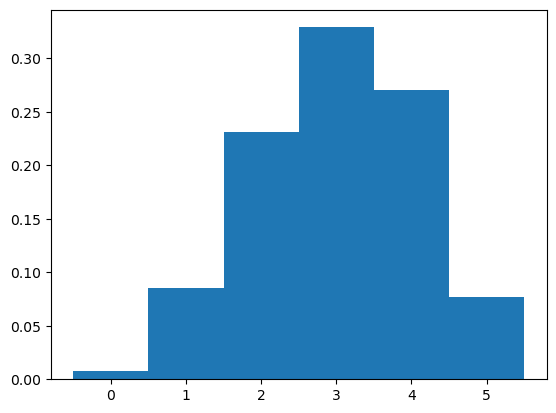

In [169]:
# my attempt
import numpy as np
import random
import matplotlib.pyplot as plt

num_samples = 5
num_trials = 1000

def sampling(rv, num_samples):
    rand_vals = [rv[random.randint(0,len(rv)-1)] for i in range(num_samples)]
    return sum(rand_vals)

def run_trials(rv, num_samples, num_trials):
    results = np.array([sampling(rv, num_samples) for i in range(num_trials)])
    return results

print(f'# Trials Run: {len(results)}')  
hist_bins = np.linspace(min(results)-0.5, max(results)+0.5, max(results)+2)   
plt.hist(run_trials(rv, num_samples, num_trials), bins=hist_bins, density=True)
plt.show()


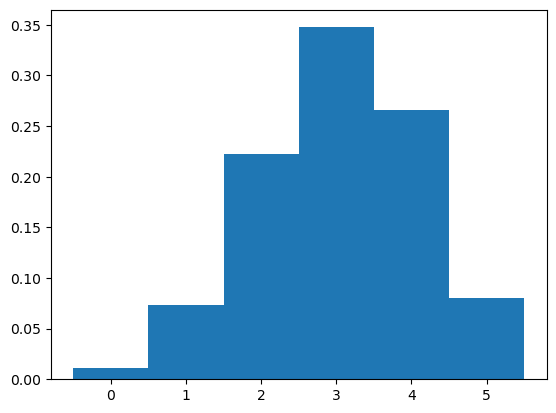

In [115]:
# sample answer
import matplotlib.pyplot as plt
import numpy as np
import random

# Sample answer
N_times = 10000
N_individual = 5

bins=np.linspace(-1,N_individual, N_individual+2)+0.5


def sumarray(N_ts, N_indiv,N):
    sums=[]    
    for i in range(N_ts):
        s = 0
        for r in range(N_indiv):
            index = random.randint(0,N-1)
            s += rv[index]
        sums.append(s)
    return sums

ss= sumarray(N_times,N_individual,N)

_=plt.hist(ss,bins=bins,density=True)
    

**Exercise three**: The central limit theorem also predicts that if one  estimates $\mu$ by the sample mean $np$
and $\sigma$ by the sample variance $np(1-p)$. Calculate these quantites for the example above. Then plot a Gaussian distribution function with these parameters in the same figure as the histogram.

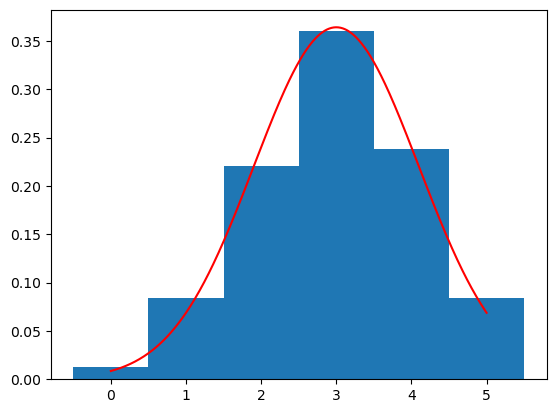

In [187]:
# my attempt
def gauss_cdf(num_samples, p):
    mu = num_samples * p
    var = mu * (1-p)
    sigma = np.sqrt(var)
    return mu,sigma

def plot_results(num_samples, num_trials, p):
    results = run_trials(rv, num_samples, num_trials)
    
    mu,sigma = gauss_cdf(num_samples, p)
    x = np.linspace(min(results),max(results),max(results)*100)
    y = norm.pdf(x,loc=mu,scale=sigma)
    
    hist_bins = np.linspace(-0.5, max(results)+0.5, max(results)+2)
    plt.hist(results, bins=hist_bins, density=True)
    plt.plot(x,y,c='r')
    plt.show()

num_samples = 5
num_trials = 1000
p = 0.6

plot_results(num_samples, num_trials, p)

3.0 1.0954451150103324


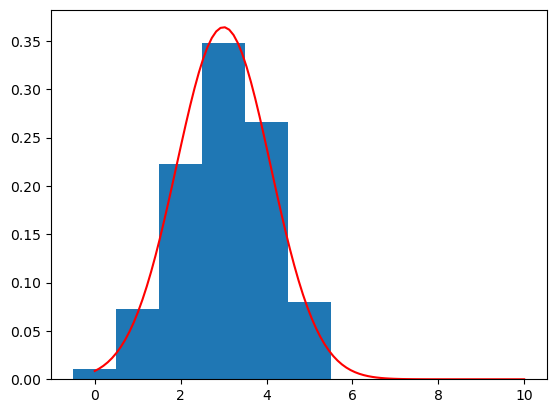

In [136]:
from scipy.stats import *
m = N_individual*p
s = np.sqrt(N_individual*p*(1-p))
x = np.linspace(0,10,100)
y = norm.pdf(x, loc=m,scale=s)
print(m, s)
_=plt.hist(ss,bins=bins,density=True)
plt.plot(x,y,'r-')

**Exercise four**:  Now repeat the entire process with not five, but twenty individuals. Explain whether the agreement is better or worse than for five individuals and expect whether this is what you expected.

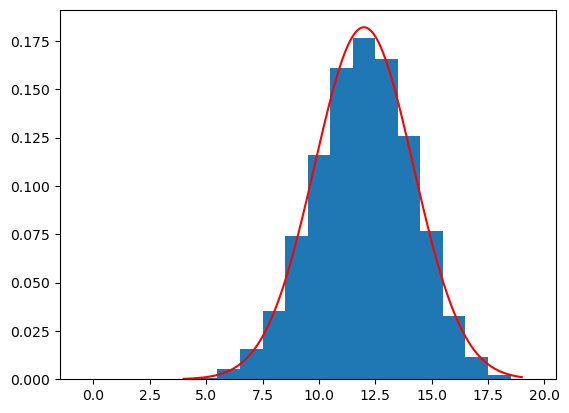

In [189]:
# my attempt
num_samples = 20
num_trials = 10000
p = 0.6

plot_results(num_samples, num_trials, p)

The results are a much stronger fit for n = 20 than it is for n = 5, as predicted by the Central Limit Theory.

12.0 2.1908902300206647


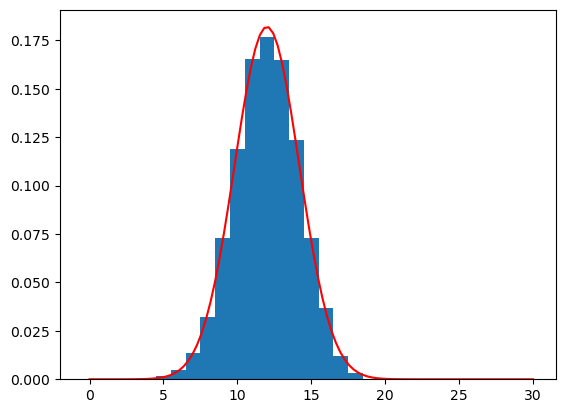

In [176]:
# sample answer

N_times = 10000
N_individual = 20
bins=np.linspace(-1,N_individual, N_individual+2)+0.5
ss= sumarray(N_times,N_individual,N)

m = N_individual*p
s = np.sqrt(N_individual*p*(1-p))
x = np.linspace(0,30,100)
y = norm.pdf(x, loc=m,scale=s)
print(m, s)
_=plt.hist(ss,bins=bins,density=True)
plt.plot(x,y,'r-')